# Figure 1 - Chromatin Deconvolution

Show the chromatin deconvolution figures and layout into panel.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [85]:
from src.Figure1_deconvolution import Figure1Deconvolution

fig1 = Figure1Deconvolution()

Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 999) to (16, 26, 100)
Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 999) to (15, 26, 100)


In [101]:
from src.figure_configs import save_figure_for_paper
from src.utils import mkdir_safe

output_dir = 'output/draft3_run/'
save_dir = f'{output_dir}/fig_chromatin_deconvolution'
mkdir_safe(save_dir)

Creating directory: output/draft3_run//fig_chromatin_deconvolution...Directory exists. Skipping.


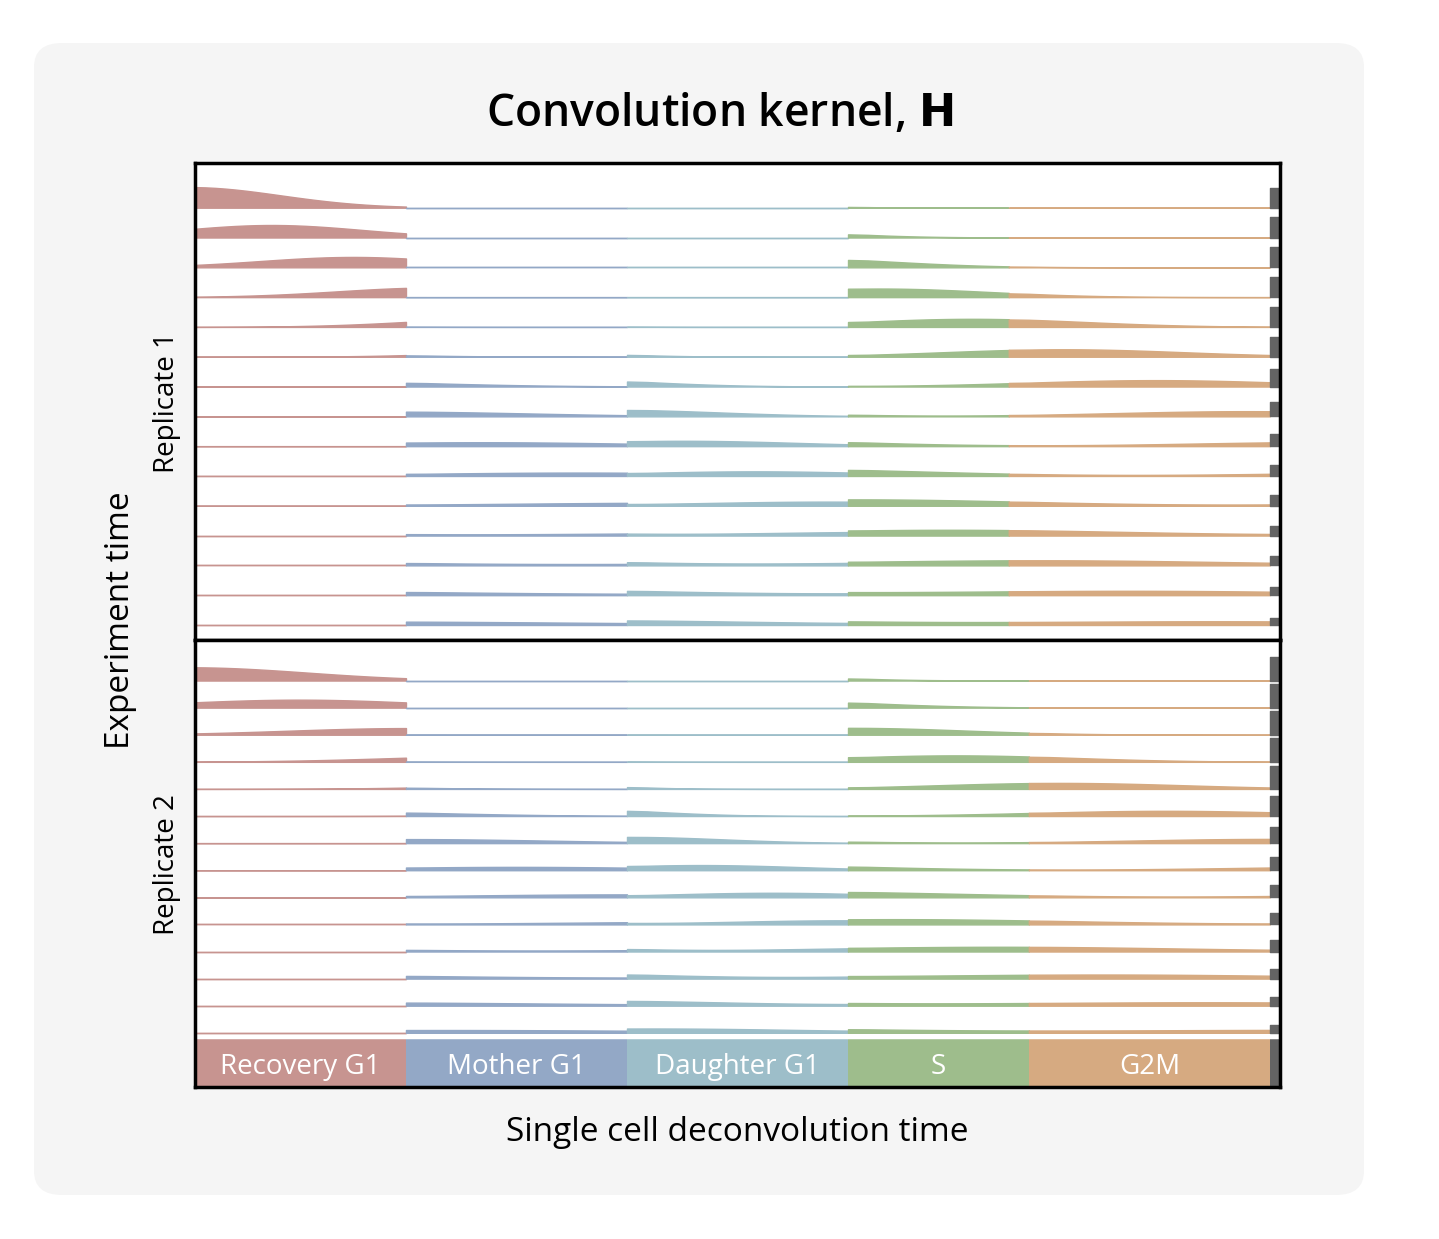

In [156]:
fig, axs = fig1.plot_H_matrices()
save_figure_for_paper(f"{save_dir}/Kernel_H_diagram.png")

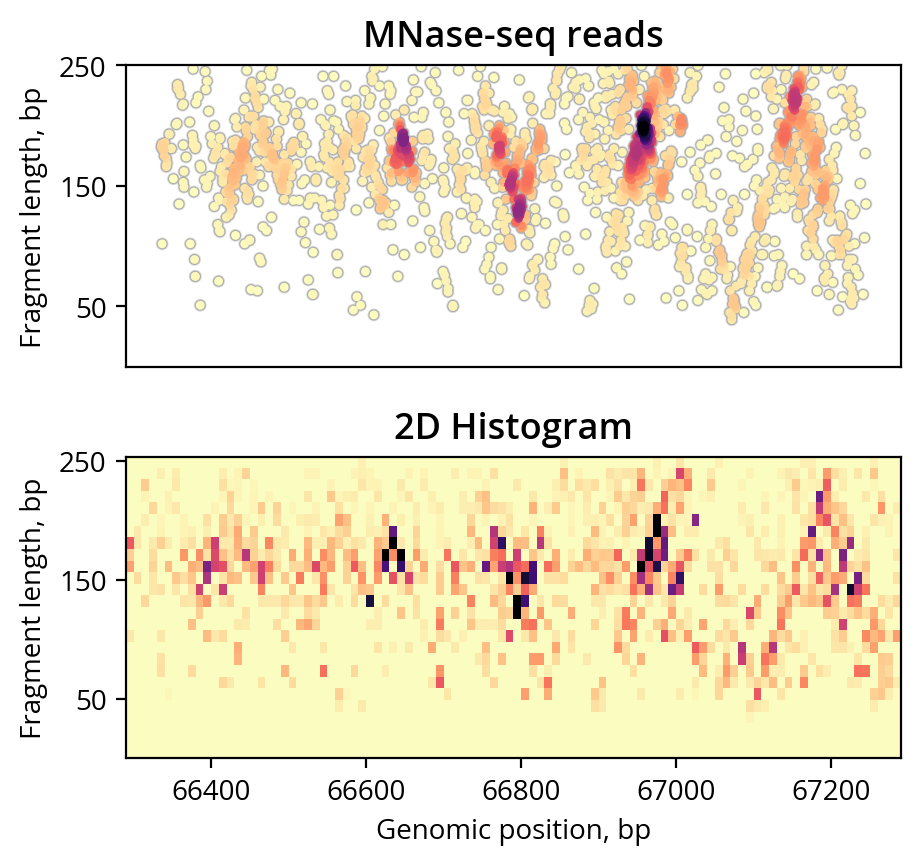

In [144]:
fig1.plot_mnase_reads_histogram()
save_figure_for_paper(f"{save_dir}/MNase_2D_Histogram.png")


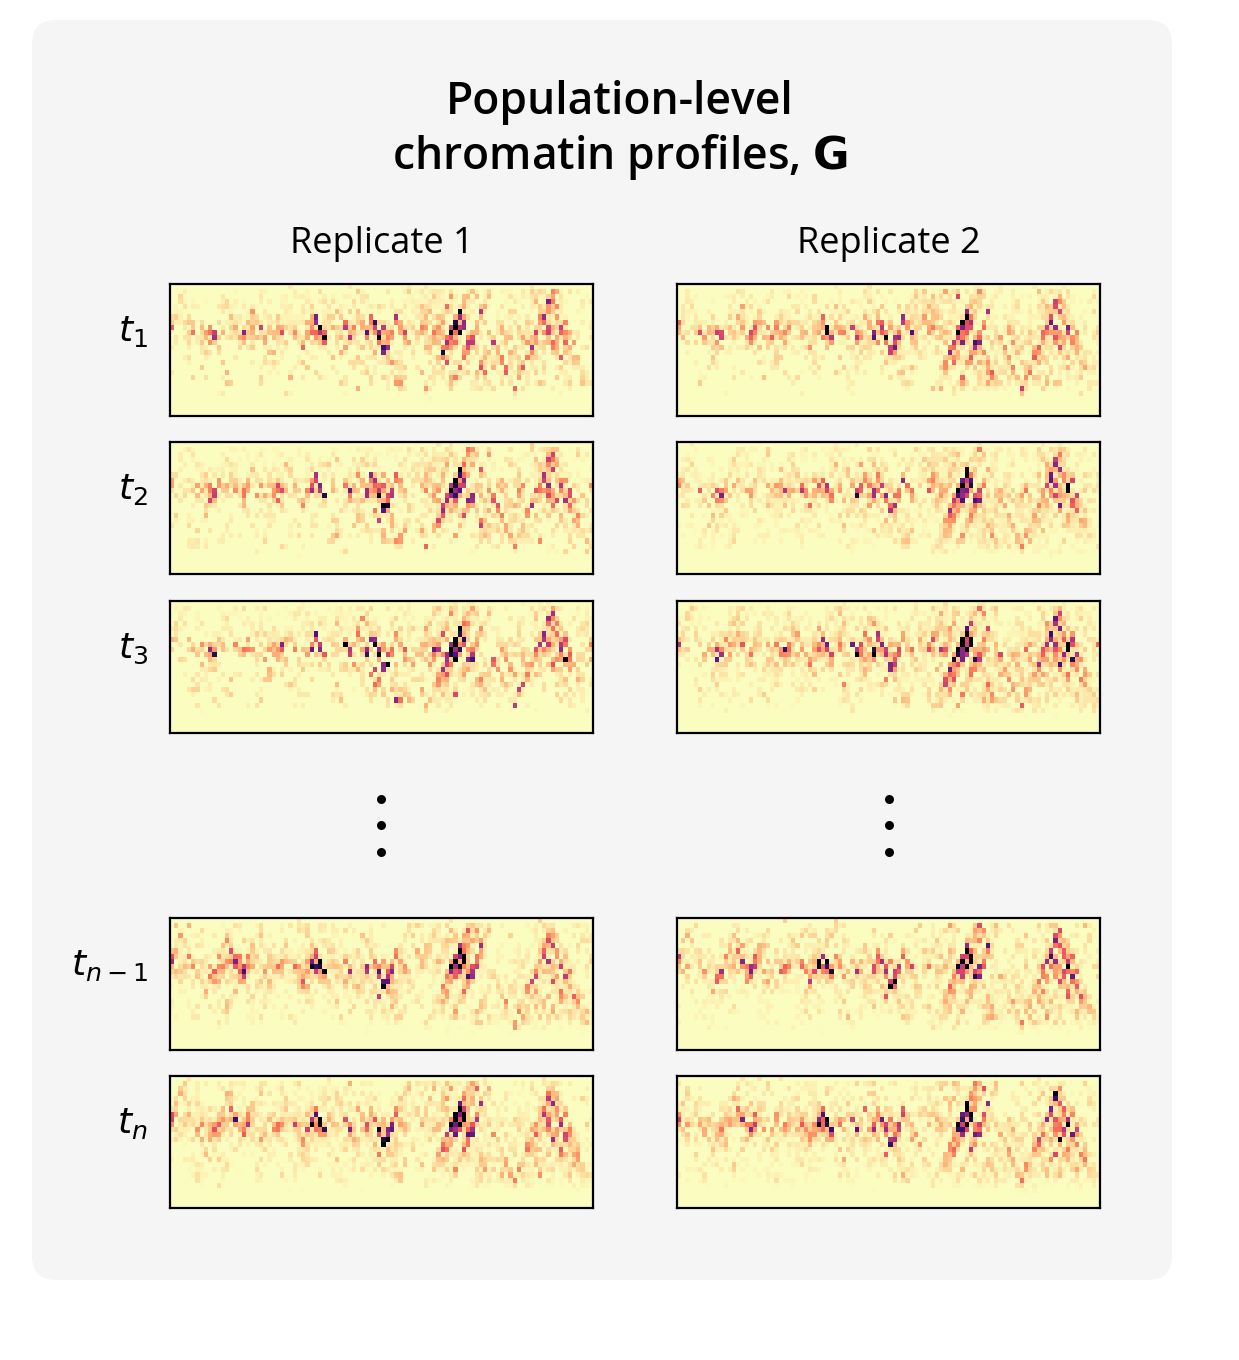

In [147]:
fig1.plot_chromatin_profiles_G()
save_figure_for_paper(f"{save_dir}/Chromatin_profiles_G.png")

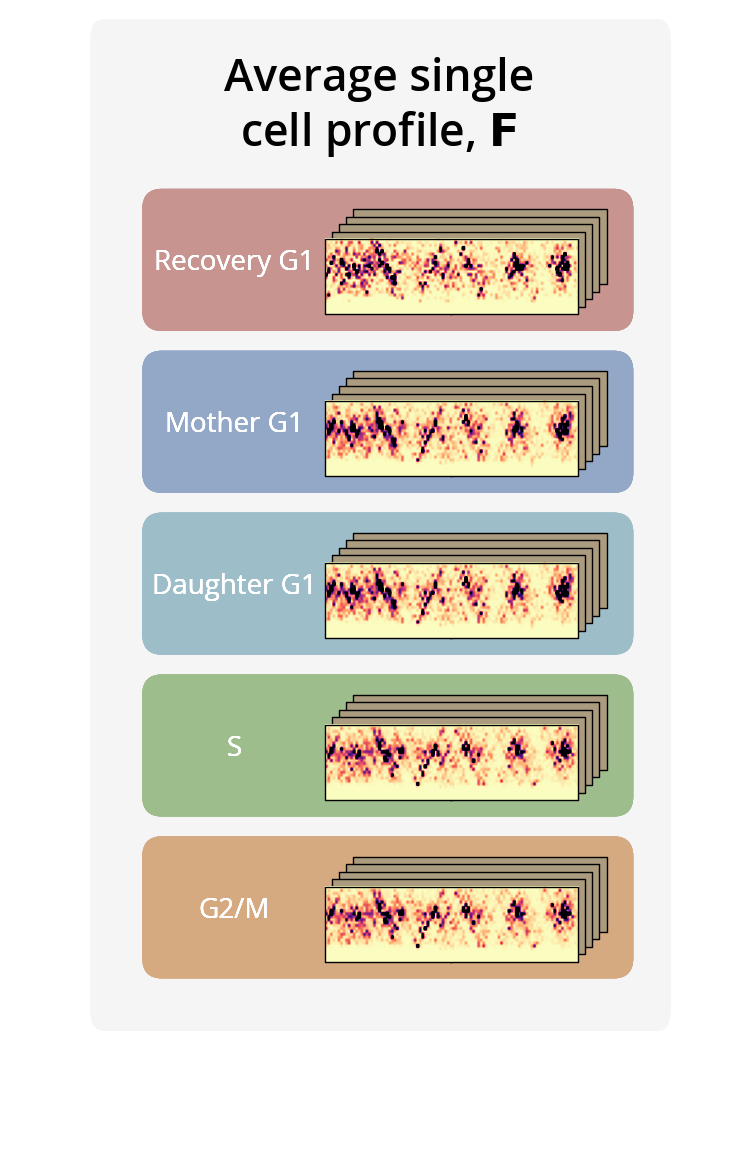

In [216]:
chromatin_data_path = 'output/draft3_run/chromatin_deconvolution_partial_daughter/'\
		    'deconvolution_data/'
fig1.plot_deconvolved_phase_annotated(chromatin_data_path)
save_figure_for_paper(f"{save_dir}/Deconvolved_Profiles_F.png")


Debug figure saved to: output/draft3_run//fig_chromatin_deconvolution/Fig1_debug.png
Clean figure saved to: output/draft3_run//fig_chromatin_deconvolution/Fig1.png


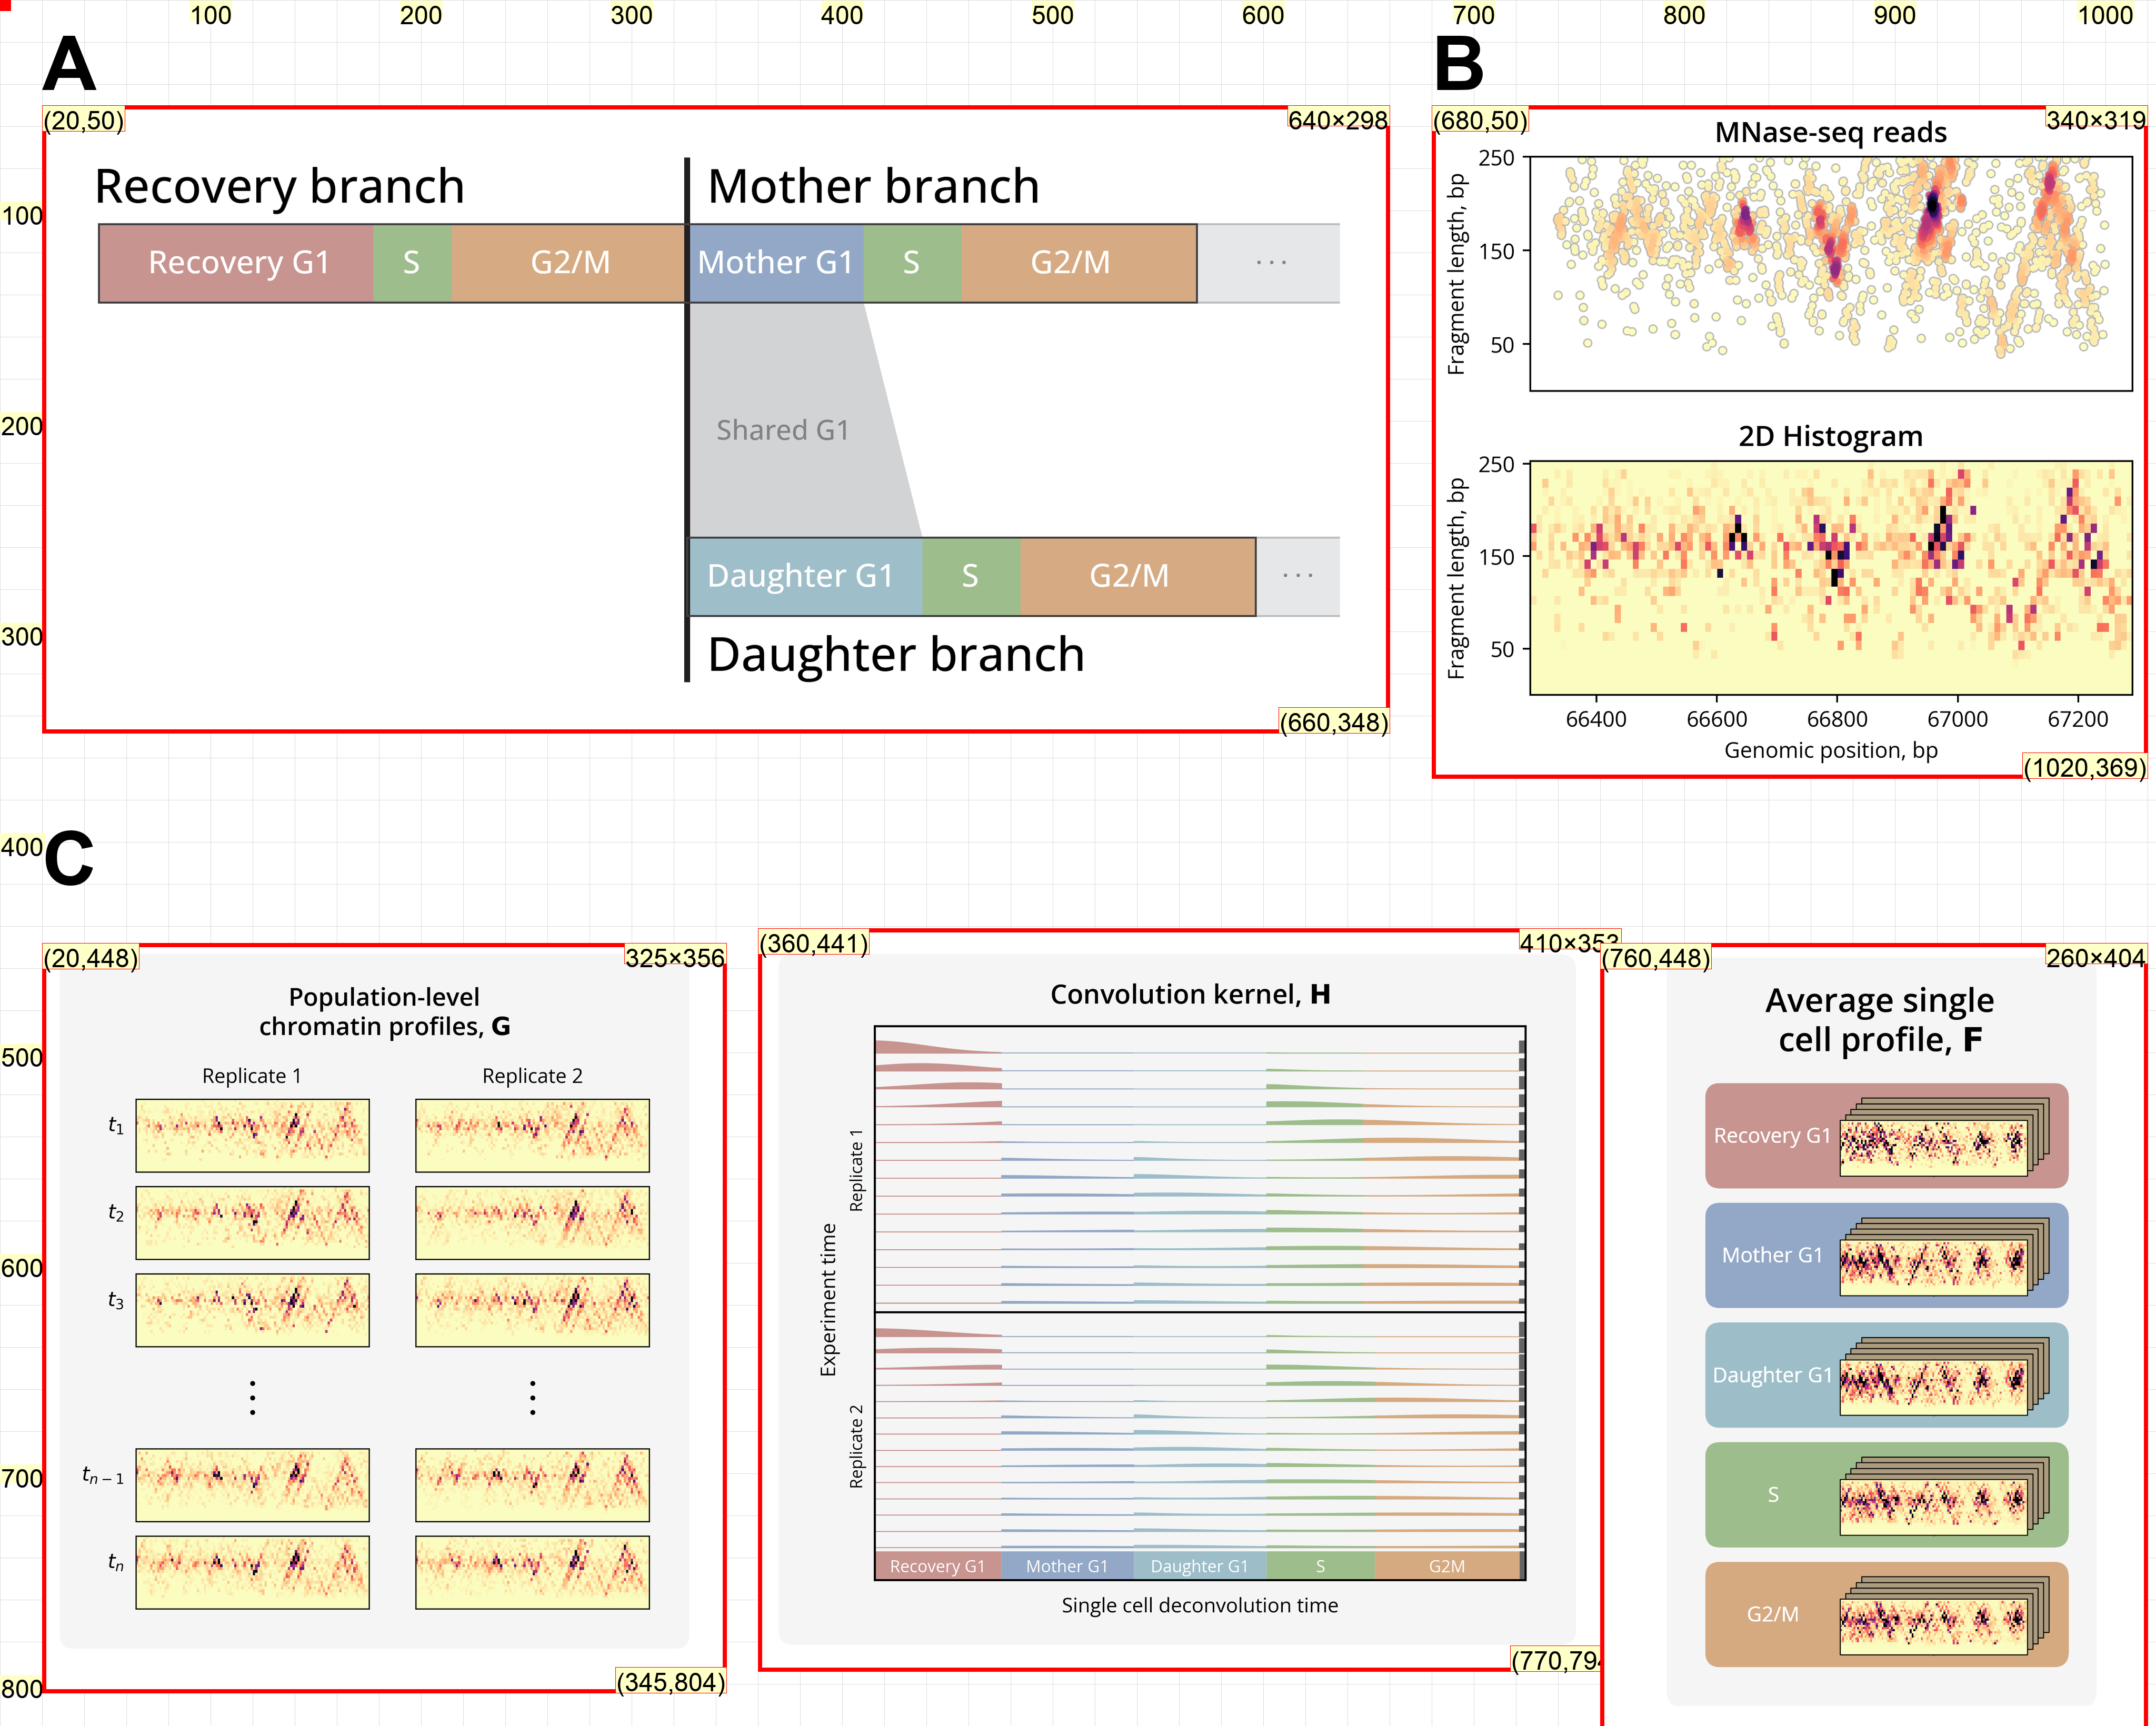

In [286]:
from pipeline.figure_composer import FigureCompositor

image_names = [
    # A, B
    'Branching_Diagram',
    'MNase_2D_Histogram', 
    
    # C
    'Chromatin_profiles_G',
    'Kernel_H_diagram',
    'Deconvolved_Profiles_F',
]

image_paths = [f"{save_dir}/{name}.png" for name in image_names]

# Create compositor with a scale factor of 4
# Logical canvas size is 1024x800, but actual output will be 4096x3200
compositor = FigureCompositor(1024, 820, debug_mode=True)

margin = 20

top_margin = margin+30

branch_img = compositor.place_image(image_paths[0], margin, top_margin, 640, None, 'branch')
compositor.add_panel_label_to_image('branch', 'A', offset=(0, -40),
                                   font_size=36)

branch_width = branch_img['logical_size'][0]
branch_height = branch_img['logical_size'][1]
padding = 20
compositor.place_image(image_paths[1], margin+branch_width+padding, top_margin, 340, None, 
    'hist')
compositor.add_panel_label_to_image('hist', 'B', offset=(0, -40),
                                   font_size=36)

# ---------- C panels

vertical_pad = 100
g_img = compositor.place_image(image_paths[2], margin, 
    top_margin+branch_height+vertical_pad, 
    325, None, 
    'raw')
compositor.add_panel_label_to_image('raw', 'C', offset=(0, -60),
    font_size=36)

g_width = g_img['logical_size'][0]
padding = 15
h_img = compositor.place_image(image_paths[3], 
    margin+g_width+padding, 
    top_margin+branch_height+vertical_pad-7,
    410, None, 
    'H')

h_width = h_img['logical_size'][0]
compositor.place_image(image_paths[4], 
    margin+g_width+padding+h_width-10, 
    top_margin+branch_height+vertical_pad, 
    260, None, 
    'F')

compositor.save(f"{save_dir}/Fig1.png")
from IPython.display import Image, display
display(Image(f'{save_dir}/Fig1_debug.png'))

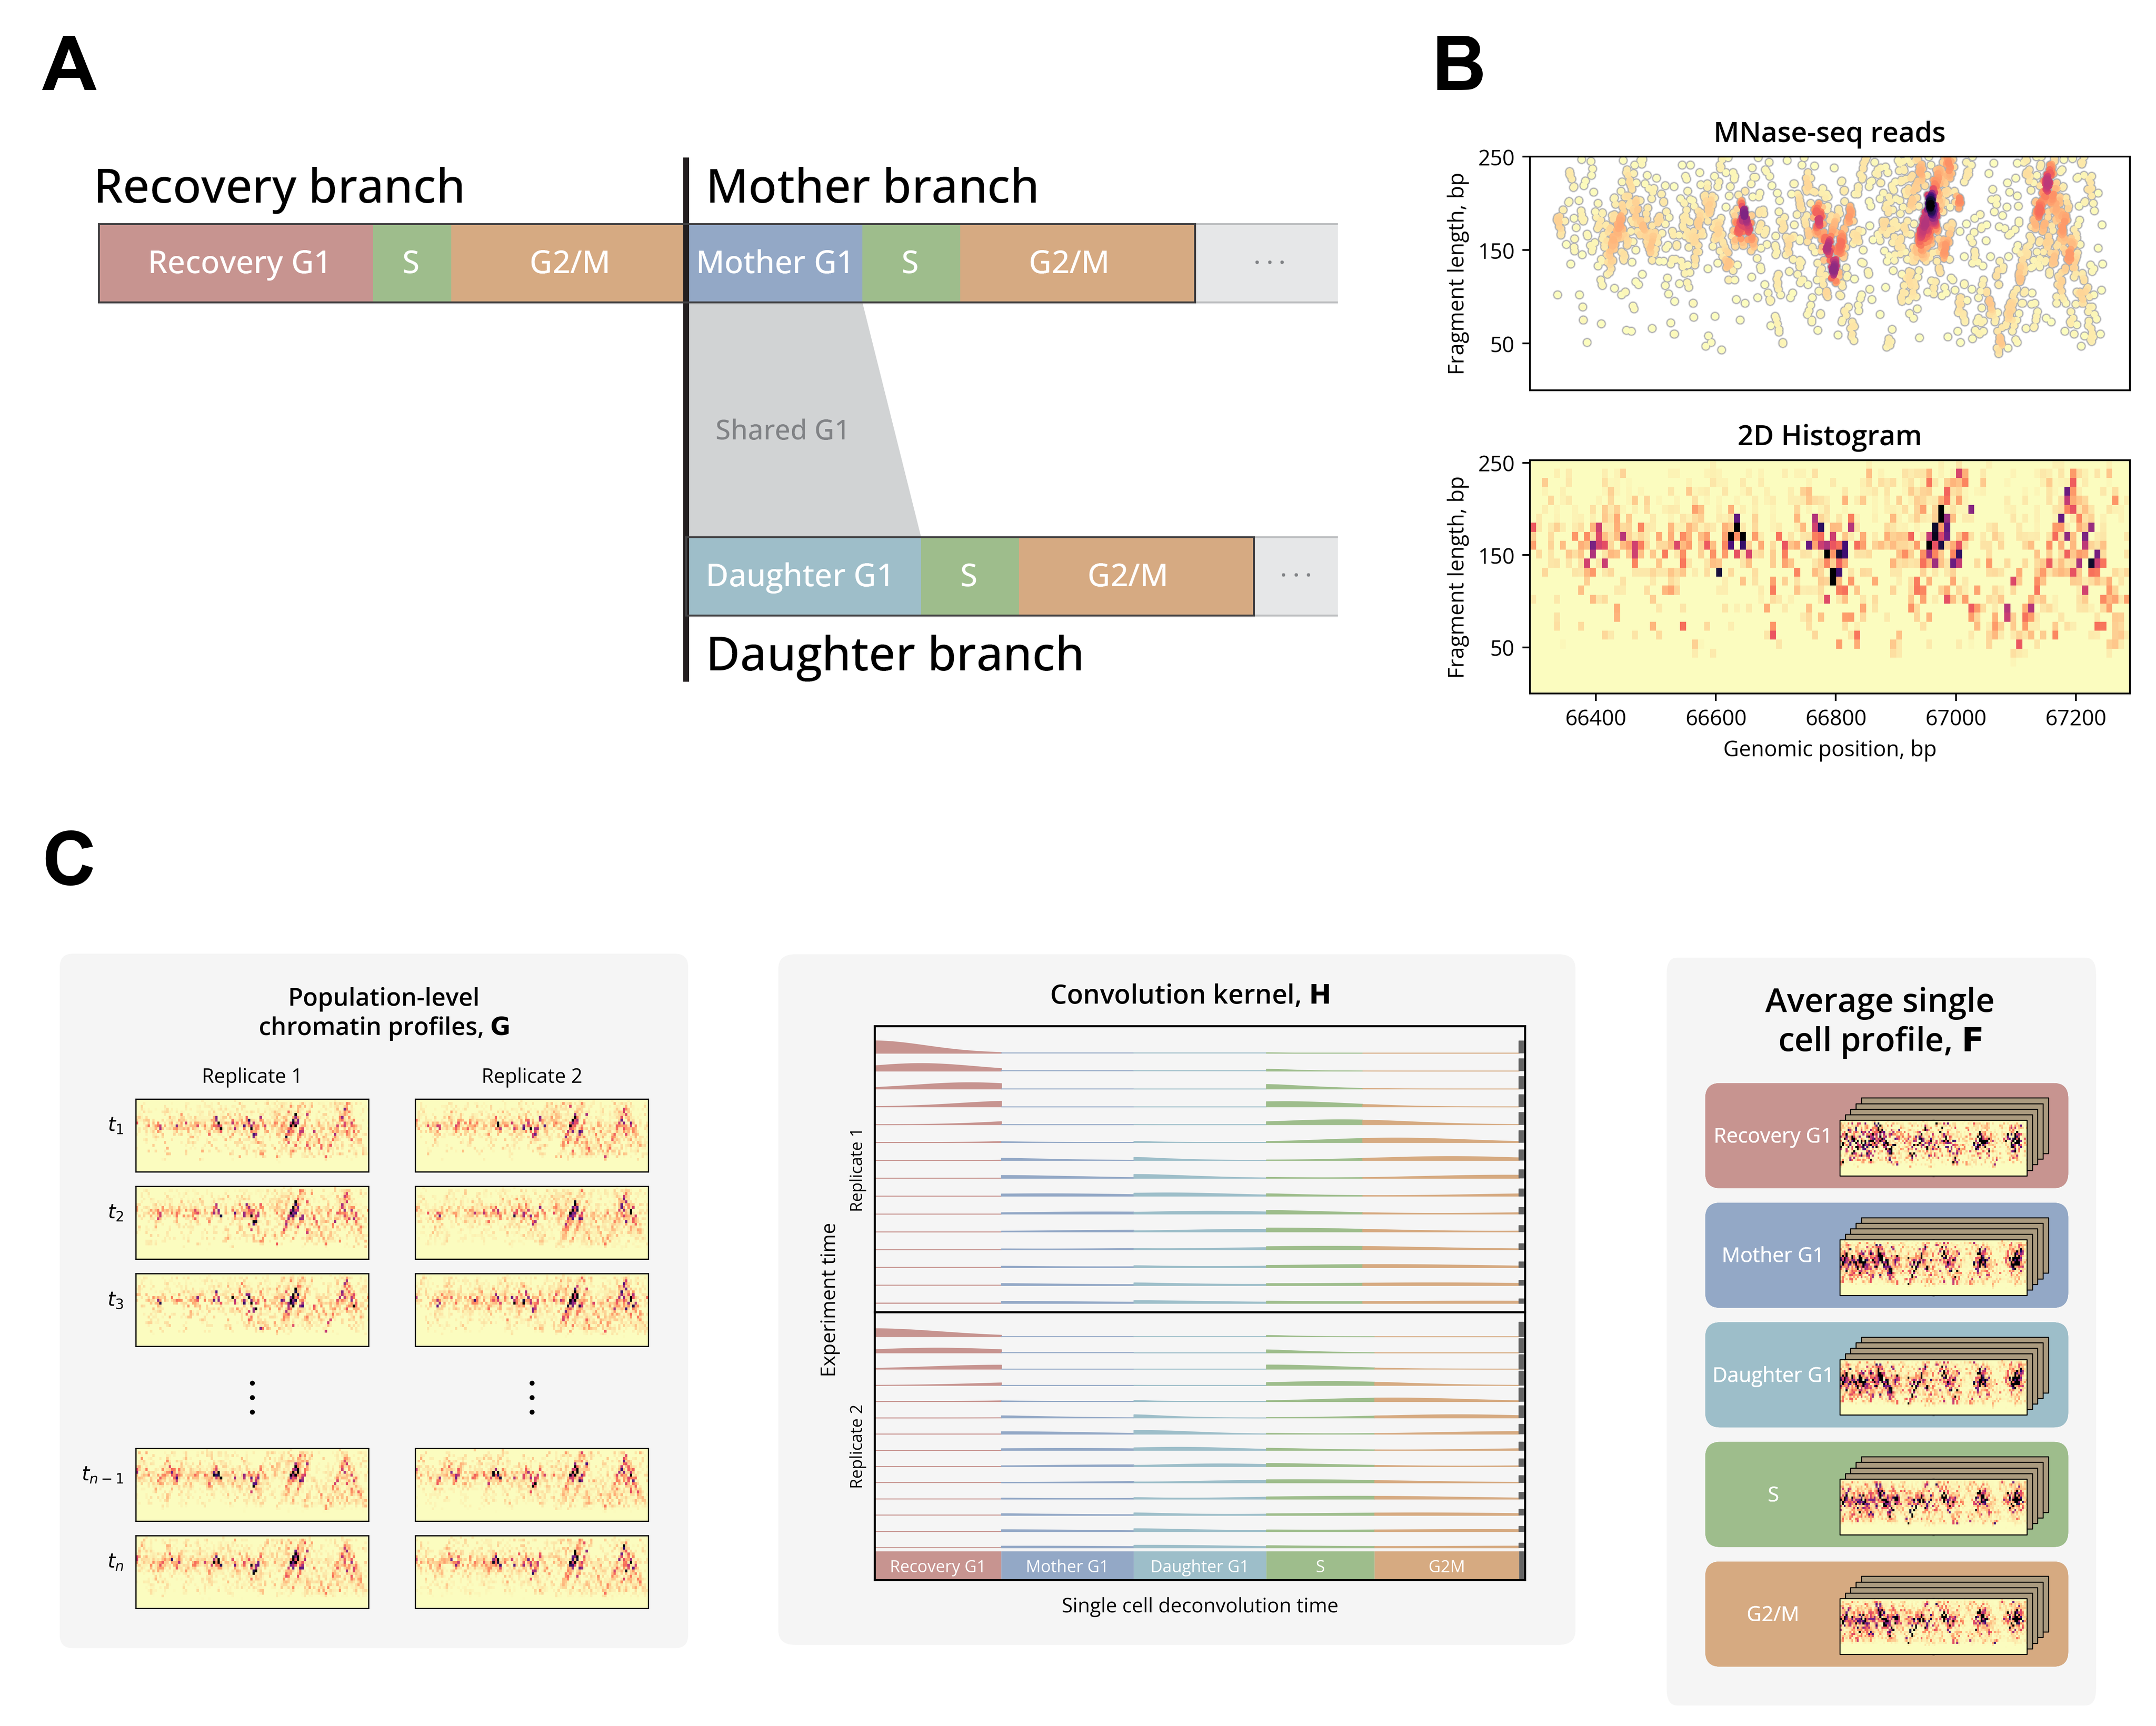

In [287]:
display(Image(f'{save_dir}/Fig1.png'))